In [12]:
import sys
import os

# Get the absolute path to the 'python' directory (one level up from 'notebooks')
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)


In [13]:
from Utils.FilePaths import *

In [14]:
import pandas as pd
import matplotlib as plt

In [15]:
COPERNICUS

PosixPath('/Users/jo/Documents/Ai_Engineering/Projects/Jo2Seb/files/data/lfs/Copernicus')

In [16]:
data_folder = COPERNICUS

In [17]:
files = list(Path.glob(data_folder, '*.csv'))

In [18]:
files

[PosixPath('/Users/jo/Documents/Ai_Engineering/Projects/Jo2Seb/files/data/lfs/Copernicus/Sentinel-5P NO2-NO2_large-area.csv'),
 PosixPath('/Users/jo/Documents/Ai_Engineering/Projects/Jo2Seb/files/data/lfs/Copernicus/Sentinel-5P SO2-SO2_large-area.csv'),
 PosixPath('/Users/jo/Documents/Ai_Engineering/Projects/Jo2Seb/files/data/lfs/Copernicus/Sentinel-5P NO2-NO2_small-area.csv'),
 PosixPath('/Users/jo/Documents/Ai_Engineering/Projects/Jo2Seb/files/data/lfs/Copernicus/Sentinel-5P SO2-SO2_small-area.csv')]

In [19]:
df_no2 = pd.read_csv(files[2], index_col=0)
df_no2.index = pd.to_datetime(df_no2.index, format="%m-%d-%y")

In [20]:
df_no2.head(20)

,C0/min,C0/max,C0/mean,C0/stDev,C0/sampleCount,C0/noDataCount,C0/median,C0/p10,C0/p90
C0/date,,,,,,,,,
2018-05-02,0.000052,0.000148,0.000088,0.000024,150,0,0.000084,0.000065,0.000142
2018-05-03,0.000029,0.000066,0.000048,0.000013,150,115,0.000057,0.000029,0.000066
2018-05-04,0.000084,0.000542,0.000282,0.000123,150,0,0.000268,0.000151,0.000453
2018-05-05,0.000019,0.000091,0.000054,0.000017,150,0,0.000053,0.000032,0.000076
2018-05-06,0.000019,0.000062,0.000036,0.000013,150,0,0.000033,0.000020,0.000057
2018-05-07,0.000018,0.000093,0.000057,0.000023,150,0,0.000055,0.000028,0.000093
2018-05-08,0.000028,0.000083,0.000053,0.000017,150,0,0.000048,0.000034,0.000082
2018-05-09,0.000025,0.000091,0.000054,0.000018,150,0,0.000048,0.000034,0.000083
2018-05-12,0.000036,0.000074,0.000052,0.000011,150,17,0.000048,0.000038,0.000067


In [21]:
df_no2.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1543 entries, 2018-05-02 to 2026-03-12
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   C0/min          1543 non-null   float64
 1   C0/max          1543 non-null   float64
 2   C0/mean         1543 non-null   float64
 3   C0/stDev        1543 non-null   float64
 4   C0/sampleCount  1543 non-null   int64  
 5   C0/noDataCount  1543 non-null   int64  
 6   C0/median       1543 non-null   float64
 7   C0/p10          1543 non-null   float64
 8   C0/p90          1543 non-null   float64
dtypes: float64(7), int64(2)
memory usage: 120.5 KB


<Axes: title={'center': 'NO2 measurements for Hamburg-City'}, xlabel='C0/date'>

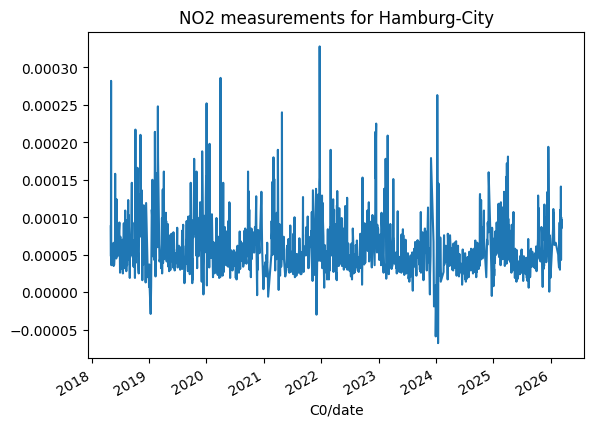

In [ ]:
df_no2["C0/mean"].plot(kind="line", title="NO2 measurements for Hamburg-City")

In [25]:

import plotly.io as pio
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats
import json
import warnings
warnings.filterwarnings("ignore")

s = df_no2["C0/mean"] * 1e4   # scale to ×10⁻⁴ mol/m²
s.name = "C0/mean"

col = "C0/mean"
unit_label = "NO₂ (mol/m²)"
SCALE = 1e4  # display as ×10⁻⁴ mol/m²

s = df_no2[col] * SCALE
s.name = col

# ── 1. Resample helpers ──────────────────────────────────────────────────────
s_monthly = s.resample("ME").mean()
s_yearly  = s.resample("YE").mean()

# ── 2. Monthly seasonal means (climatology) ─────────────────────────────────
monthly_clim = s.groupby(s.index.month).mean()
dow_clim     = s.groupby(s.index.dayofweek).mean()

# ── 3. Seasonal decomposition (weekly freq → 365 for yearly) ─────────────────
s_daily_full = s.resample("D").mean().interpolate()
decomp = seasonal_decompose(s_daily_full, model="additive", period=365, extrapolate_trend="freq")

# ── 4. Fit SARIMA(1,1,1)(1,1,0,12) on monthly series ────────────────────────
s_monthly_clean = s_monthly.dropna()
sarima = SARIMAX(s_monthly_clean, order=(1,1,1), seasonal_order=(1,1,0,12),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fitted      = sarima.fittedvalues
residuals   = sarima.resid
forecast    = sarima.get_forecast(12)
fc_mean     = forecast.predicted_mean
fc_ci       = forecast.conf_int()

# ── 5. Year-over-year matrix ─────────────────────────────────────────────────
df_yoy = s.copy().to_frame()
df_yoy["year"]  = df_yoy.index.year
df_yoy["month"] = df_yoy.index.month
pivot = df_yoy.groupby(["year","month"])[col].mean().unstack("month")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

colors = pio.templates["plotly"].layout.colorway

# ════════════════════════════════════════════════════════════════════════════
# PLOT 1 – Raw time series + 30-day rolling mean
# ════════════════════════════════════════════════════════════════════════════
fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=s.index, y=s.values,
    mode="lines", name="Daily",
    line=dict(width=0.8, color=colors[0]),
    opacity=0.4
))
roll = s.rolling(30, center=True).mean()
fig1.add_trace(go.Scatter(
    x=roll.index, y=roll.values,
    mode="lines", name="30-day avg",
    line=dict(width=2.5, color=colors[1])
))
fig1.update_layout(
    title={"text": "Hamburg NO₂ Raw Series (2018–2026)<br><span style='font-size:16px;font-weight:normal'>Sentinel-5P | Seasonal winter peaks clearly visible</span>"},
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
)
fig1.update_xaxes(title_text="Date")
fig1.update_yaxes(title_text="NO₂ ×10⁻⁴ mol/m²")
fig1.write_image("no2_raw_series.png")
with open("no2_raw_series.png.meta.json","w") as f:
    json.dump({"caption":"Hamburg NO₂ daily values with 30-day rolling mean (2018–2026)","description":"Raw Sentinel-5P NO2 time series with rolling average overlay"}, f)

# ════════════════════════════════════════════════════════════════════════════
# PLOT 2 – Seasonal Decomposition (4-panel)
# ════════════════════════════════════════════════════════════════════════════
fig2 = make_subplots(rows=4, cols=1, shared_xaxes=True,
    subplot_titles=["Observed","Trend","Seasonal (yearly)","Residuals"],
    vertical_spacing=0.06)

components = [
    (decomp.observed,  colors[0]),
    (decomp.trend,     colors[1]),
    (decomp.seasonal,  colors[2]),
    (decomp.resid,     colors[3]),
]
for i, (comp, c) in enumerate(components, 1):
    fig2.add_trace(go.Scatter(x=comp.index, y=comp.values,
        mode="lines", line=dict(width=1.2 if i < 4 else 0.8, color=c),
        showlegend=False), row=i, col=1)

fig2.update_layout(
    title={"text": "NO₂ Seasonal Decomposition (Additive, period=365)<br><span style='font-size:16px;font-weight:normal'>Sentinel-5P Hamburg | Strong yearly seasonality</span>"},
    height=900
)
fig2.update_yaxes(title_text="×10⁻⁴", row=1, col=1)
fig2.update_xaxes(title_text="Date", row=4, col=1)
fig2.write_image("no2_decomp.png")
with open("no2_decomp.png.meta.json","w") as f:
    json.dump({"caption":"Seasonal decomposition of NO₂ into trend, seasonal and residuals","description":"4-panel additive decomposition plot"}, f)

# ════════════════════════════════════════════════════════════════════════════
# PLOT 3 – Monthly & day-of-week climatology (side by side)
# ════════════════════════════════════════════════════════════════════════════
fig3 = make_subplots(rows=1, cols=2,
    subplot_titles=["Monthly Climatology", "Day-of-Week Pattern"],
    horizontal_spacing=0.12)

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig3.add_trace(go.Bar(
    x=month_names, y=monthly_clim.values,
    marker_color=colors[0], showlegend=False
), row=1, col=1)

dow_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
fig3.add_trace(go.Bar(
    x=dow_names, y=dow_clim.values,
    marker_color=colors[1], showlegend=False
), row=1, col=2)

fig3.update_yaxes(title_text="Avg NO₂ ×10⁻⁴", row=1, col=1)
fig3.update_yaxes(title_text="Avg NO₂ ×10⁻⁴", row=1, col=2)
fig3.update_layout(
    title={"text": "NO₂ Seasonality Patterns – Hamburg<br><span style='font-size:16px;font-weight:normal'>Sentinel-5P | Higher in winter & weekdays</span>"},
)
fig3.write_image("no2_seasonality.png")
with open("no2_seasonality.png.meta.json","w") as f:
    json.dump({"caption":"NO₂ monthly climatology and day-of-week pattern for Hamburg","description":"Bar charts of monthly and weekly NO2 averages"}, f)

# ════════════════════════════════════════════════════════════════════════════
# PLOT 4 – Year-over-year monthly heatmap
# ════════════════════════════════════════════════════════════════════════════
fig4 = go.Figure(go.Heatmap(
    z=pivot.values,
    x=pivot.columns.tolist(),
    y=[str(y) for y in pivot.index.tolist()],
    colorscale="RdYlGn_r",
    colorbar=dict(title="×10⁻⁴ mol/m²")
))
fig4.update_layout(
    title={"text": "NO₂ Monthly Heatmap per Year (Hamburg)<br><span style='font-size:16px;font-weight:normal'>Sentinel-5P | Long-term seasonal pattern & trend</span>"},
)
fig4.update_xaxes(title_text="Month")
fig4.update_yaxes(title_text="Year")
fig4.write_image("no2_heatmap.png")
with open("no2_heatmap.png.meta.json","w") as f:
    json.dump({"caption":"Year-over-year NO₂ heatmap by month for Hamburg","description":"Heatmap showing NO2 intensity per month and year"}, f)

# ════════════════════════════════════════════════════════════════════════════
# PLOT 5 – SARIMA fit, residuals & 12-month forecast
# ════════════════════════════════════════════════════════════════════════════
fig5 = make_subplots(rows=2, cols=1, shared_xaxes=False,
    subplot_titles=["SARIMA(1,1,1)(1,1,0)[12] Fit & 12-Month Forecast",
                    "Model Residuals"],
    vertical_spacing=0.12)

# observed monthly
fig5.add_trace(go.Scatter(x=s_monthly_clean.index, y=s_monthly_clean.values,
    mode="lines", name="Observed", line=dict(color=colors[0], width=2)), row=1, col=1)

# fitted
fig5.add_trace(go.Scatter(x=fitted.index, y=fitted.values,
    mode="lines", name="Fitted", line=dict(color=colors[1], width=1.5, dash="dot")), row=1, col=1)

# forecast + CI
fig5.add_trace(go.Scatter(
    x=list(fc_mean.index) + list(fc_mean.index[::-1]),
    y=list(fc_ci.iloc[:,1]) + list(fc_ci.iloc[:,0][::-1]),
    fill="toself", fillcolor=f"rgba(99,110,250,0.2)",
    line=dict(color="rgba(255,255,255,0)"),
    name="95% CI", showlegend=True), row=1, col=1)
fig5.add_trace(go.Scatter(x=fc_mean.index, y=fc_mean.values,
    mode="lines", name="Forecast", line=dict(color=colors[2], width=2.5)), row=1, col=1)

# residuals
fig5.add_trace(go.Bar(x=residuals.index, y=residuals.values,
    name="Residuals", marker_color=colors[3], showlegend=False), row=2, col=1)
fig5.add_hline(y=0, line_color="white", line_dash="dot", row=2, col=1)

fig5.update_yaxes(title_text="NO₂ ×10⁻⁴", row=1, col=1)
fig5.update_yaxes(title_text="Residual", row=2, col=1)
fig5.update_xaxes(title_text="Date", row=2, col=1)
fig5.update_layout(
    title={"text": "SARIMA Model: Fit, Forecast & Residuals<br><span style='font-size:16px;font-weight:normal'>Monthly NO₂ | Hamburg | 12-month outlook</span>"},
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
    height=800
)
fig5.write_image("no2_sarima.png")
with open("no2_sarima.png.meta.json","w") as f:
    json.dump({"caption":"SARIMA model fit, 12-month forecast and residuals for Hamburg NO₂","description":"Two-panel plot showing SARIMA fitted values with forecast and residual bar chart"}, f)

# ════════════════════════════════════════════════════════════════════════════
# PLOT 6 – Residual QQ + histogram
# ════════════════════════════════════════════════════════════════════════════
res_clean = residuals.dropna()
qq = stats.probplot(res_clean, dist="norm")
theoretical_q, sample_q = qq[0]
fit_line_y = qq[1][0] * theoretical_q + qq[1][1]

fig6 = make_subplots(rows=1, cols=2,
    subplot_titles=["Residual QQ-Plot", "Residual Distribution"],
    horizontal_spacing=0.12)

fig6.add_trace(go.Scatter(x=theoretical_q, y=sample_q,
    mode="markers", name="Quantiles",
    marker=dict(color=colors[0], size=5)), row=1, col=1)
fig6.add_trace(go.Scatter(x=theoretical_q, y=fit_line_y,
    mode="lines", name="Normal fit",
    line=dict(color=colors[1], width=2, dash="dash")), row=1, col=1)

fig6.add_trace(go.Histogram(x=res_clean.values, nbinsx=30,
    name="Residuals", marker_color=colors[2], showlegend=False), row=1, col=2)

fig6.update_xaxes(title_text="Theoretical Q", row=1, col=1)
fig6.update_yaxes(title_text="Sample Q", row=1, col=1)
fig6.update_xaxes(title_text="Residual value", row=1, col=2)
fig6.update_yaxes(title_text="Count", row=1, col=2)
fig6.update_layout(
    title={"text": "Residual Diagnostics – SARIMA Model<br><span style='font-size:16px;font-weight:normal'>Hamburg NO₂ | Near-normal residuals</span>"},
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
)
fig6.write_image("no2_residual_diag.png")
with open("no2_residual_diag.png.meta.json","w") as f:
    json.dump({"caption":"SARIMA residual QQ-plot and histogram for Hamburg NO₂","description":"Residual normality diagnostics showing QQ-plot and histogram"}, f)

print("All 6 plots saved.")
print(f"SARIMA AIC: {sarima.aic:.2f}")
print(f"Residual mean: {res_clean.mean():.6f}, std: {res_clean.std():.6f}")


All 6 plots saved.
SARIMA AIC: -115.50
Residual mean: 0.001245, std: 0.306642
